In [1]:
%run CleanData.ipynb

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPool1D,
    Dropout, Dense, MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [3]:
# ==================== OPTIONAL: extra scaling ====================
# comment out if CleanData already normalised signals
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [4]:
# ==================== reshape & one-hot ==========================
X_train = X_train.reshape((-1, X_train.shape[1], 1))
X_test  = X_test.reshape((-1,  X_test.shape[1], 1))


num_classes = 6
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

# ===== validation split =====
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train, y_train_cat,
    test_size=0.15, stratify=y_train,
    random_state=42
)

In [5]:
# ==================== focal-loss CLASS ===========================
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=1.0,
                 from_logits=False,
                 reduction='sum_over_batch_size',
                 name='focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma       = gamma
        self.alpha       = tf.constant(alpha, dtype=tf.float32)
        self.from_logits = from_logits

    def call(self, y_true, y_pred):        # <-- fixed name
        y_true = tf.cast(y_true, y_pred.dtype)
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        alpha_t = (tf.reduce_sum(y_true * self.alpha, axis=-1)
                   if self.alpha.shape.rank == 1 else self.alpha)
        focal = tf.pow(1.0 - p_t, self.gamma)
        loss  = -alpha_t * focal * tf.math.log(tf.clip_by_value(p_t, 1e-7, 1.0))
        return loss

In [6]:
# ===== focal-loss instance =====
alpha_vec = [class_weights[i] for i in range(len(class_weights))]
loss_fn   = FocalLoss(gamma=2.0, alpha=alpha_vec, from_logits=True)

In [7]:
# ----------- hyper-params you already have -------------
SEQ_LEN, N_CHANNELS = X_train.shape[1:]
NUM_CLASSES = 6
HEADS       = 4        # 4 heads × 32 dim = 128 attn hidden
EMBED_DIM   = 32

# ----------- model -------------------------------------
inp = Input(shape=(SEQ_LEN, N_CHANNELS))

# (1) Convolutional feature extractor
x = Conv1D(64, 5, padding='same', activation='relu')(inp)
x = BatchNormalization()(x)
x = MaxPool1D(2)(x)

x = Conv1D(128, 5, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPool1D(2)(x)                # output shape ≈ (SEQ_LEN/4, 128)

# (2) Linear projection → even embedding dim for attention
proj = Dense(EMBED_DIM)(x)         # (None, T, 32)

# (3) Transformer-lite block (single layer)
attn_out = MultiHeadAttention(num_heads=HEADS,
                              key_dim=EMBED_DIM // HEADS)(proj, proj, proj)
attn_out = Dropout(0.2)(attn_out)
add_1    = Add()([proj, attn_out])         # residual
norm_1   = LayerNormalization()(add_1)

ffn      = Dense(4*EMBED_DIM, activation='relu')(norm_1)
ffn      = Dense(EMBED_DIM)(ffn)
ffn      = Dropout(0.2)(ffn)
add_2    = Add()([norm_1, ffn])            # residual
norm_2   = LayerNormalization()(add_2)

s_idx   = np.where(np.argmax(y_train_cat,1) == 1)[0]
repeatS = tf.data.Dataset.from_tensor_slices((X_train[s_idx], y_train_cat[s_idx])).repeat()
big_ds  = tf.data.Dataset.from_tensor_slices((X_train, y_train_cat))
train_ds = big_ds.concatenate(repeatS).shuffle(len(X_train)*2).batch(256)
# (4) Global pooling + output head
glob = GlobalAveragePooling1D()(norm_2)
logits = Dense(NUM_CLASSES)(glob)          # raw logits (for focal loss)

model_attn = Model(inp, logits)
model_attn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 133, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 133, 64)   │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 133, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 66, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 66, 128)   │     41,088 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 66, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 33, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 33, 32)    │      4,128 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 33, 32)    │      4,224 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0],      │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 33, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 33, 32)    │          0 │ dense[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 33, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 33, 128)   │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 33, 32)    │      4,128 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 33, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 33, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 33, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │        198 │ global_average_p

 Total params: 59,270 (231.52 KB)

 Trainable params: 58,886 (230.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
minor_ds = tf.data.Dataset.from_tensor_slices(
              (X_train[s_idx], y_train_cat[s_idx]))  # S beats
main_ds  = tf.data.Dataset.from_tensor_slices(
              (X_train, y_train_cat))                # all beats

train_ds = tf.data.Dataset.sample_from_datasets(
              [main_ds, minor_ds],
              weights=[0.85, 0.15]    # 30 % of every batch will be S beats
          ).shuffle(len(X_train)*2
          ).batch(256
          ).prefetch(tf.data.AUTOTUNE)


# 1️⃣  Focal-loss instance (reuse your class_weights vector)
alpha_vec = [class_weights[i] for i in range(len(class_weights))]
loss_fn   = FocalLoss(gamma=2.5,       # a bit higher focus on hard examples
                      alpha=alpha_vec,
                      from_logits=True)

# 2️⃣  Compile
model_attn.compile(
    optimizer = Adam(1e-3),
    loss      = loss_fn,               # <-- focal loss here
    metrics   = [
        'accuracy',
        tf.keras.metrics.Precision(name='prec'),
        tf.keras.metrics.Recall(name='rec'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_pr_auc', factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_pr_auc', mode='max',
        patience=8, restore_best_weights=True, verbose=1)
]

history_attn = model_attn.fit(
    train_ds,
    validation_data=(X_val, y_val_cat),
    epochs    = 20,
    callbacks = callbacks,
    verbose   = 2
)


Epoch 1/20


c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


337/337 - 30s - 88ms/step - accuracy: 0.8408 - loss: 0.3250 - pr_auc: 0.5087 - prec: 0.4109 - rec: 0.9611 - val_accuracy: 0.0737 - val_loss: 3.1543 - val_pr_auc: 0.1402 - val_prec: 0.0755 - val_rec: 0.1556 - learning_rate: 1.0000e-03
Epoch 2/20
337/337 - 38s - 111ms/step - accuracy: 0.8983 - loss: 0.1643 - pr_auc: 0.4875 - prec: 0.4108 - rec: 0.9897 - val_accuracy: 0.8781 - val_loss: 0.2037 - val_pr_auc: 0.4680 - val_prec: 0.4112 - val_rec: 0.9817 - learning_rate: 1.0000e-03
Epoch 3/20
337/337 - 35s - 104ms/step - accuracy: 0.9170 - loss: 0.1245 - pr_auc: 0.4921 - prec: 0.4208 - rec: 0.9930 - val_accuracy: 0.9299 - val_loss: 0.1098 - val_pr_auc: 0.4883 - val_prec: 0.4182 - val_rec: 0.9921 - learning_rate: 1.0000e-03
Epoch 4/20

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
337/337 - 92s - 272ms/step - accuracy: 0.9247 - loss: 0.1075 - pr_auc: 0.4897 - prec: 0.4219 - rec: 0.9951 - val_accuracy: 0.9337 - val_loss: 0.1077 - val_pr_auc: 0.5112 - val_prec: 0.43

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report
)
import seaborn as sns   # nicer heat-map

# ---------------------------------------------------------------
def visualize_training(history,
                       X_test, y_test_cat,
                       class_labels,
                       batch_size=256,
                       cols=3,
                       cmap="Blues"):
    """
    history       : Keras History object (or its .history dict)
    X_test        : test features (ndarray, same shape model.predict expects)
    y_test_cat    : one-hot test labels (ndarray)
    class_labels  : list of str for axis ticks
    cols          : how many plots per row
    cmap          : matplotlib colormap for confusion matrix
    """
    # ----------- pull curves -----------------------------------
    hist = history.history if hasattr(history, "history") else history
    epochs = np.arange(1, len(hist["loss"]) + 1)

    # ----------- build canvas ----------------------------------
    n_plots = 4                                      # loss, acc, pr-auc, cm
    rows    = int(np.ceil(n_plots / cols))
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 5, rows * 4))
    axes = axes.flatten()

    # 1 Loss
    axes[0].plot(epochs, hist["loss"], label="train")
    axes[0].plot(epochs, hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend()

    # 2 Accuracy
    axes[1].plot(epochs, hist["accuracy"], label="train")
    axes[1].plot(epochs, hist["val_accuracy"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Acc")
    axes[1].legend()

    # 3 PR-AUC (skip if missing)
    if "pr_auc" in hist:
        axes[2].plot(epochs, hist["pr_auc"], label="train")
        axes[2].plot(epochs, hist["val_pr_auc"], label="val")
        axes[2].set_title("PR-AUC")
        axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("PR-AUC")
        axes[2].legend()
    else:
        axes[2].axis("off")

    # 4 Confusion matrix on test set
    probs   = model_attn.predict(X_test, batch_size=batch_size, verbose=0)
    y_true  = np.argmax(y_test_cat, axis=1)
    y_pred  = np.argmax(probs,        axis=1)
    cm      = confusion_matrix(y_true, y_pred, normalize="true")

    sns.heatmap(cm,
                cmap=cmap, annot=True, fmt=".2f",
                xticklabels=class_labels,
                yticklabels=class_labels,
                ax=axes[3])
    axes[3].set_xlabel("Predicted"); axes[3].set_ylabel("True")
    axes[3].set_title("Normalized Confusion Matrix")

    # hide any unused subplot spaces
    for ax in axes[n_plots:]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()

    # ----------- optional: print per-class metrics -------------
    print(pd.DataFrame(
        classification_report(y_true, y_pred,
                              target_names=class_labels,
                              output_dict=True)).T)
# ---------------------------------------------------------------


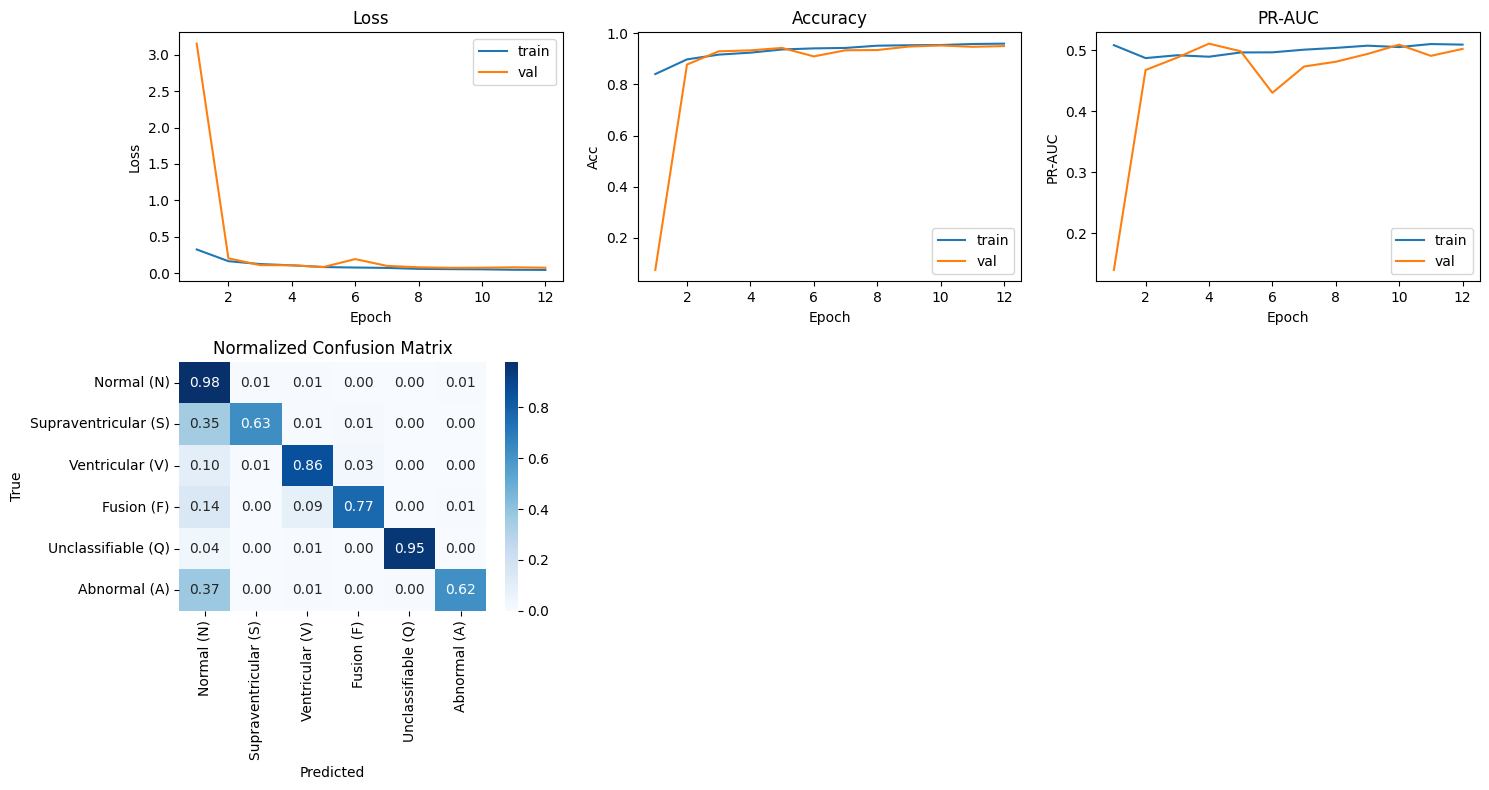

                      precision    recall  f1-score       support
Normal (N)             0.938980  0.979211  0.958673  18952.000000
Supraventricular (S)   0.721992  0.625899  0.670520    556.000000
Ventricular (V)        0.899494  0.859116  0.878841   1448.000000
Fusion (F)             0.521008  0.765432  0.620000    162.000000
Unclassifiable (Q)     0.981350  0.949005  0.964907   1608.000000
Abnormal (A)           0.927589  0.616755  0.740891   2077.000000
accuracy               0.930573  0.930573  0.930573      0.930573
macro avg              0.831736  0.799236  0.805639  24803.000000
weighted avg           0.930874  0.930573  0.927508  24803.000000


In [10]:
class_labels = [
    "Normal (N)", "Supraventricular (S)",
    "Ventricular (V)", "Fusion (F)",
    "Unclassifiable (Q)", "Abnormal (A)"
]

visualize_training(
    history     = history_attn,   # or history from GRU model
    X_test      = X_test,
    y_test_cat  = y_test_cat,
    class_labels= class_labels,
    cols        = 3               # 3 plots per row → 2 compact rows
)


C:\Users\plui0\AppData\Local\Temp\ipykernel_9788\3307647448.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


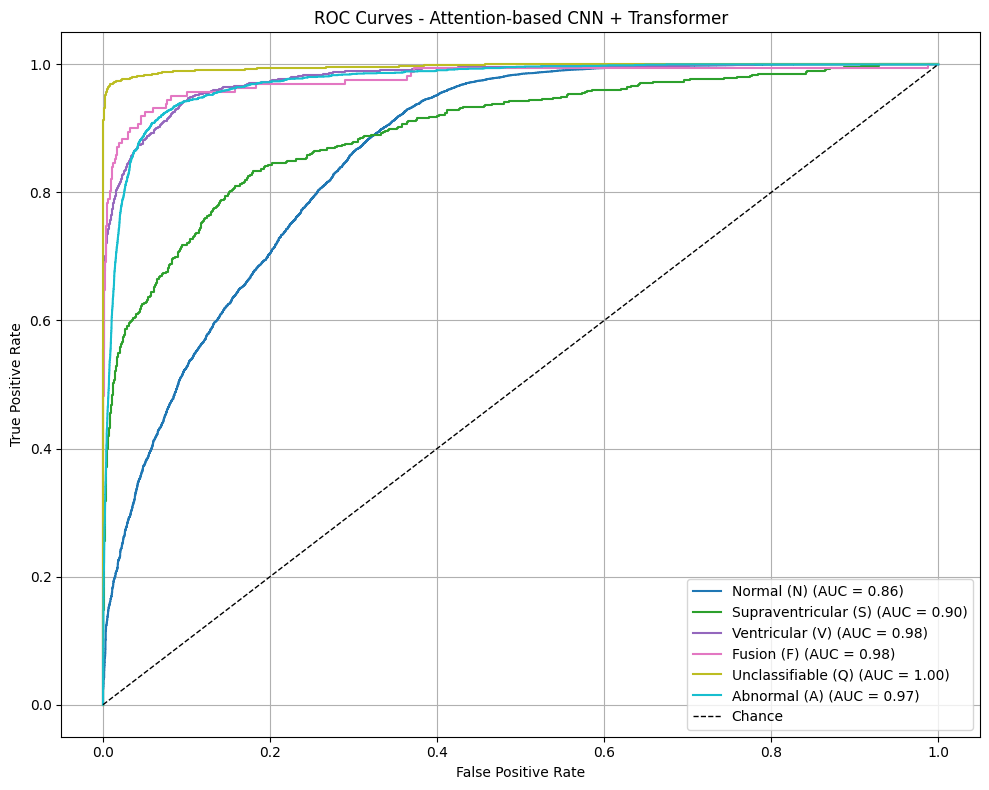

In [11]:
# ==================== ROC & AUC ====================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Convert labels to binary format for ROC
y_true = np.argmax(y_test_cat, axis=1)
y_score = model_attn.predict(X_test, batch_size=256, verbose=0)
y_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', num_classes)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})",
             color=colors(i))

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Attention-based CNN + Transformer")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
